In [16]:
#Lenard Jones Potential
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Open Sans']})
rc('text', usetex=True)
plt.rcParams.update({'font.size': 14})

In [17]:
def LJ_potential(r, sigma, epsilon):
    """Calculate the Lennard-Jones potential."""
    return 4 * epsilon * ((sigma / r)**12 - (sigma / r)**6)


gaz = ["Ne", "Ar", "Kr"]
sigma = [2.78, 3.41, 3.6] # en Angström
epsilon = [34.9, 119.8, 171.0] # en K


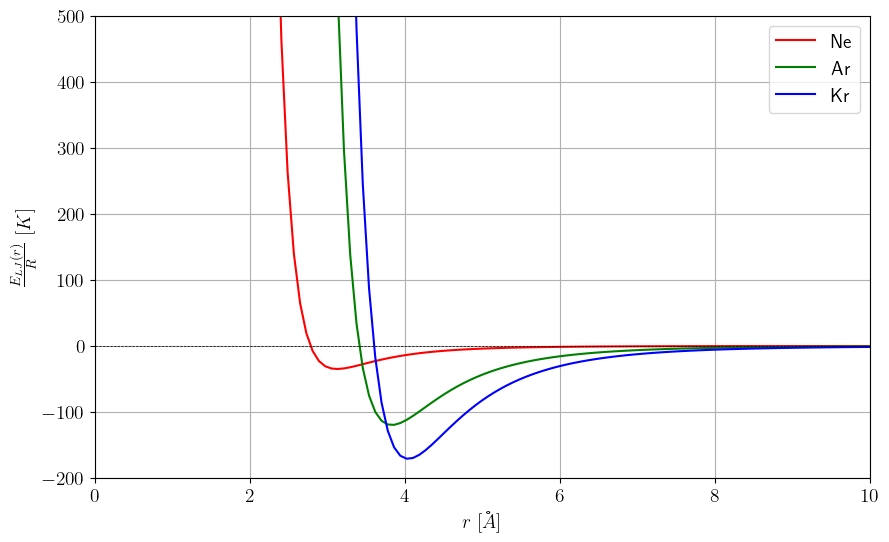

In [18]:
colors = 'red', 'green', 'blue'
r = np.linspace(2, 10, 100) # en Angström


fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
for i in range(len(gaz)):
    ax.plot(r, LJ_potential(r, sigma[i], epsilon[i]), 
            label=gaz[i], color=colors[i])

ax.set_ylim(-200, 500)
ax.set_xlim(0, 10)

ax.set_ylabel("$\\frac{E_{LJ}(r)}{R} ~ [K]$")
ax.set_xlabel("$r ~ [Å]$")

ax.axhline(0, color='black', lw=0.5, ls='--')
ax.legend()

ax.grid()

fig.savefig("Corr01.pdf", dpi=300)

In [19]:
Tfus = [24.56, 83.81, 115.79] # en K
Teb = [27.07, 87.30, 119.93] # en K

fit_Tfus = np.poly1d(np.polyfit(epsilon, Tfus, 1))
fit_Teb = np.poly1d(np.polyfit(epsilon, Teb, 1))

print("Fit Tfus:", fit_Tfus)
print("Fit Teb:", fit_Teb)

Fit Tfus:  
0.6731 x + 1.644
Fit Teb:  
0.685 x + 3.729


<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_84428/411462036.py:7: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel("Énergie d'interaction / du puit $\epsilon$ [K]")


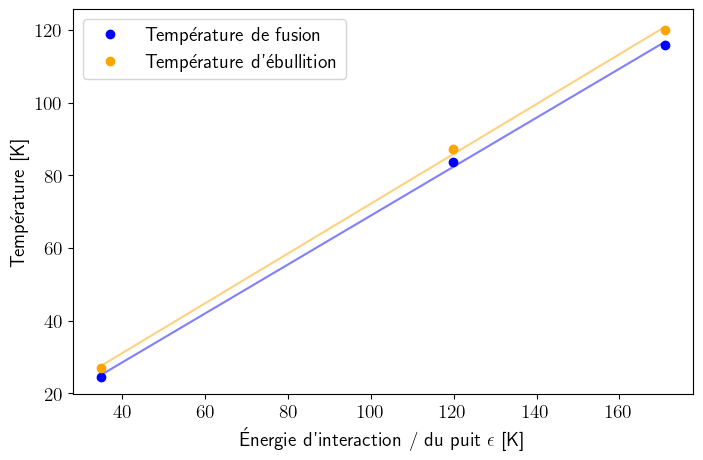

In [20]:
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)
ax.plot(epsilon, Tfus, 'o', label="Température de fusion", color ='blue')
ax.plot(epsilon, fit_Tfus(epsilon), '-', color='blue', alpha=0.5)
ax.plot(epsilon, Teb, 'o', label="Température d'ébullition", color ='orange')
ax.plot(epsilon, fit_Teb(epsilon), '-', color='orange', alpha=0.5)
ax.set_xlabel("Énergie d'interaction / du puit $\epsilon$ [K]")
ax.set_ylabel("Température [K]")
ax.legend()

fig.savefig("Corr02.pdf", dpi=300)